In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from gensim.models import Word2Vec
import langid
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import optuna

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, Subset

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import AutoTokenizer, AutoModelForSequenceClassification, RobertaForSequenceClassification, Trainer, TrainingArguments

# Load and examine data

In [2]:
# Reading in the csv file
poem_data=pd.read_csv("Data/Poem_c4.csv",index_col=0)

print("The dataset has columns :", " and ".join(poem_data.columns))
print("Number of unique topics:", poem_data['topic'].nunique())
print("The topics are :", ", ".join(poem_data['topic'].unique()))
print("There are ",poem_data.shape[0], "entries.")

The dataset has columns : poem and topic
Number of unique topics: 5
The topics are : religion, love, nature, relationships, arts&sciences
There are  10064 entries.


In [3]:
poem_data.head()

,poem,topic
0,Sunday we lay hands\non a girl of ten hand on ...,religion
1,O transient voyager of heaven!\n⁠ ⁠ ⁠ O silent...,religion
2,\n\n\na cento for Sarah Hegazy\n\n\n\n\na cent...,religion
3,"I am in the middle of “The Fourteen Poems"" by ...",religion
4,"I lift him out, whole and perfect.\nSaid told ...",religion


In [4]:
# output example poem
poem_data.loc[0, "poem"]

'Sunday we lay hands\non a girl of ten hand on hand on\ncornsilk hair. We sing\nthe secret language sung\nthe day the tin roof of the tower beat\non God’s floorboard\nhe got cramp in heaven.\nLike our crying and our\nfornicating so close to his bed\nwas so many shrill mice in a pretty\npine floor. To heal\nthe girl with the crippled up leg\nGod sends back the song\nhe took and down it comes\ncontrary in one mouth as fire\ngentle on our bodies as rain.\nSoft rain swells the Cumberland\nand all her fields in April nuzzles\nbuttercups the mules won’t touch\nthe crowpoison the wake-robin\nthe bluets of the field.\nEvery song got a beat beneath.\nStart with the whippoorwill\nearly meadow colors creep\ninto the sky. My sons made this\ntobacco sled I prime with the jenny\ntoss the last of the sandlugs for the rest\nto thrive. So hot the wasps hang on the honeysuckle\ntoo spent to buzz a sermon.\nI know my song remembers\nwhat my fathers told their strings.\nDriskill, KentuckyDriskill, Kentuck

In [5]:
# check for null entries
poem_data.isnull().sum()

poem     0
topic    0
dtype: int64

In [6]:
# checking distribution of each class
topic_counts = poem_data['topic'].value_counts(0)
print(topic_counts)
topic_percentage = poem_data['topic'].value_counts(1)
print(topic_percentage)

topic
nature           2429
arts&sciences    2183
love             2082
relationships    1807
religion         1563
Name: count, dtype: int64
topic
nature           0.241355
arts&sciences    0.216912
love             0.206876
relationships    0.179551
religion         0.155306
Name: proportion, dtype: float64


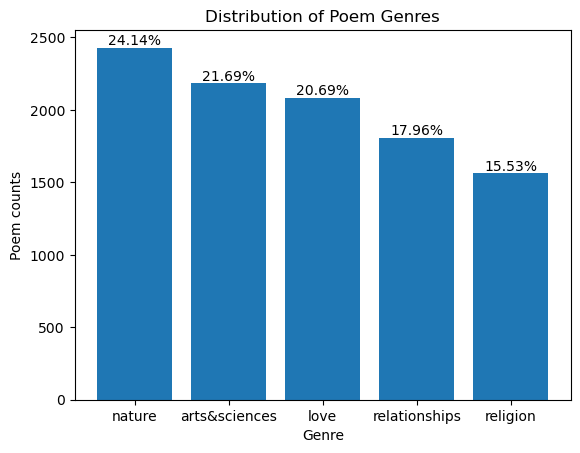

In [7]:
# create an plot to visualise the distribution of genres
percentages = (topic_counts/topic_counts.sum())*100
bars = plt.bar(topic_counts.index,topic_counts.values)

# add percentage labels
for bar, percentage in zip(bars, percentages):
    height = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, height+20,
             f'{percentage:.2f}%', ha='center')
plt.xlabel('Genre')
plt.ylabel('Poem counts')
plt.title('Distribution of Poem Genres')
plt.show()

# Pre-Processing

In [8]:
# detect and get rid of non english poems using langid
poem_data['is_english'] = poem_data['poem'].apply(lambda x: langid.classify(x)[0] == 'en')
print(poem_data['is_english'].value_counts())
print(poem_data['is_english'].value_counts(1))
poem_data = poem_data[poem_data['is_english']]

is_english
True     9929
False     135
Name: count, dtype: int64
is_english
True     0.986586
False    0.013414
Name: proportion, dtype: float64


In [9]:
stop_words = set(stopwords.words('english'))

# define a function to carry out preprocess
def data_preprocess(text):
    # lowercasing all text
    text = text.lower()
    # remove punctuation and numbers
    text = re.sub(rf"[{string.punctuation}]", " ", text)
    text = re.sub(r"\d+", "", text)
    # splitting on whitespace
    words = text.split()
    # remove stopwords
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

# store the cleaned poems in a new column "cleaned_poem"
poem_data["cleaned_poem"] = poem_data["poem"].apply(data_preprocess)

# Vectorise and train models

### TF-IDF and Logistic regression

In [10]:
# vectorise with TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(poem_data['cleaned_poem'])
# converts string labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(poem_data['topic'])

# split into train and test sets (stratify sample)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=112)
# train the logistic regression
clf = LogisticRegression(max_iter=500)
clf.fit(X_train,y_train)
# evaluate on test set
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.5191339375629406
               precision    recall  f1-score   support

arts&sciences       0.47      0.54      0.50       429
         love       0.57      0.52      0.55       412
       nature       0.50      0.68      0.58       479
relationships       0.53      0.42      0.47       357
     religion       0.61      0.34      0.44       309

     accuracy                           0.52      1986
    macro avg       0.54      0.50      0.51      1986
 weighted avg       0.53      0.52      0.51      1986



In [11]:
# to get average metrics over 10 runs
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for i in range(10):
    # train and test split
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=i)

    # train model and predict
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # get accuracy and store them
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)

    # get weighted precision, recall, f1 and store them
    precision,recall,f1, _ = precision_recall_fscore_support(y_test,y_pred,average='weighted')
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

    # print metrics for each run
    print(f"Run {i+1}: Accuracy:{acc:.5f}, Precision:{precision:.5f}, Recall:{recall:.5f}, F1:{f1:.5f}")

# get the averages
print("\nThe average metrics of 10 runs are:")
print(f"Accuracy: {np.mean(accuracy_list):.5f}")
print(f"Precision: {np.mean(precision_list):.5f}")
print(f"Recall: {np.mean(recall_list):.5f}")
print(f"F1 Score: {np.mean(f1_list):.5f}")

Run 1: Accuracy:0.51410, Precision:0.52621, Recall:0.51410, F1:0.50614
Run 2: Accuracy:0.50201, Precision:0.51899, Recall:0.50201, F1:0.49749
Run 3: Accuracy:0.51611, Precision:0.52620, Recall:0.51611, F1:0.51115
Run 4: Accuracy:0.52165, Precision:0.53862, Recall:0.52165, F1:0.51559
Run 5: Accuracy:0.50000, Precision:0.51376, Recall:0.50000, F1:0.49428
Run 6: Accuracy:0.52870, Precision:0.53933, Recall:0.52870, F1:0.52346
Run 7: Accuracy:0.53172, Precision:0.54897, Recall:0.53172, F1:0.52753
Run 8: Accuracy:0.52367, Precision:0.53830, Recall:0.52367, F1:0.51786
Run 9: Accuracy:0.51057, Precision:0.52465, Recall:0.51057, F1:0.50785
Run 10: Accuracy:0.51964, Precision:0.53063, Recall:0.51964, F1:0.51337

The average metrics of 10 runs are:
Accuracy: 0.51682
Precision: 0.53057
Recall: 0.51682
F1 Score: 0.51147


### Word2Vec and Logistic regression

In [12]:
# tokenize the poems
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())
# train Word2Vec model
w2v_model = Word2Vec(sentences=poem_data['tokens'],vector_size=100,window=5,min_count=2,workers=16)

# get average vector for each poem
def get_average_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X = np.array([get_average_vector(tokens, w2v_model) for tokens in poem_data['tokens']])

# encode labels
y = LabelEncoder().fit_transform(poem_data['topic'])
# split the train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y)

# train logistic regression
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

# evaluate the performance
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.4561933534743202
              precision    recall  f1-score   support

           0       0.40      0.46      0.43       429
           1       0.49      0.40      0.44       412
           2       0.50      0.66      0.57       479
           3       0.42      0.38      0.40       357
           4       0.48      0.30      0.37       309

    accuracy                           0.46      1986
   macro avg       0.46      0.44      0.44      1986
weighted avg       0.46      0.46      0.45      1986



In [41]:
# tokenize the poems
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())

# train Word2Vec model 
VECTOR_SIZE = 100
w2v_model = Word2Vec(sentences=poem_data['tokens'],vector_size=VECTOR_SIZE,
                     window=5,min_count=5,workers=16)

# define a function to get average word vector for each poem
def get_average_vector(tokens, model, vector_size=VECTOR_SIZE):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

# create vector representations for all poems
X = np.array([get_average_vector(tokens, w2v_model, vector_size=VECTOR_SIZE) for tokens in poem_data['tokens']])
y = LabelEncoder().fit_transform(poem_data['topic'])

# to get average metrics over 10 runs
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

# run 10 times
for i in range(10):
    # split train test sets
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=i)
    # train and predict with logistic regression
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    # evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    # get weighted average for precision recall and f1 score
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    # store the results
    accuracy_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    # print at each run
    print(f"Run {i+1}: Accuracy={acc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# print average
print("\nAverages over 10 runs:")
print(f"Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Precision (macro): {np.mean(precision_list):.4f}")
print(f"Recall (macro): {np.mean(recall_list):.4f}")
print(f"F1 Score (macro): {np.mean(f1_list):.4f}")

Run 1: Accuracy=0.4441, Precision=0.4513, Recall=0.4441, F1=0.4371
Run 2: Accuracy=0.4476, Precision=0.4537, Recall=0.4476, F1=0.4421
Run 3: Accuracy=0.4416, Precision=0.4437, Recall=0.4416, F1=0.4344
Run 4: Accuracy=0.4607, Precision=0.4628, Recall=0.4607, F1=0.4525
Run 5: Accuracy=0.4245, Precision=0.4287, Recall=0.4245, F1=0.4181
Run 6: Accuracy=0.4542, Precision=0.4587, Recall=0.4542, F1=0.4479
Run 7: Accuracy=0.4552, Precision=0.4601, Recall=0.4552, F1=0.4485
Run 8: Accuracy=0.4632, Precision=0.4664, Recall=0.4632, F1=0.4548
Run 9: Accuracy=0.4381, Precision=0.4397, Recall=0.4381, F1=0.4331
Run 10: Accuracy=0.4567, Precision=0.4639, Recall=0.4567, F1=0.4497

Averages over 10 runs:
Accuracy: 0.4486
Precision (macro): 0.4529
Recall (macro): 0.4486
F1 Score (macro): 0.4418


#### tuned Word2Vec

In [14]:
# tokenize poems
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())

# train Word2Vec model with thuned parameters
VECTOR_SIZE = 200
w2v_model = Word2Vec(sentences=poem_data['tokens'],vector_size=VECTOR_SIZE,
                     window=30,min_count=10,workers=16)

# define a function to get average word vector for each poem
def get_average_vector(tokens, model, vector_size=VECTOR_SIZE):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

# create vector representations for all poems
X = np.array([get_average_vector(tokens, w2v_model, vector_size=VECTOR_SIZE) for tokens in poem_data['tokens']])
y = LabelEncoder().fit_transform(poem_data['topic'])

# to get average metrics over 10 runs
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

# run 10 times
for i in range(10):
    # split train test sets
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=i)
    # train and predict with logistic regression
    clf = LogisticRegression(max_iter=500)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    # evaluate metrics
    acc = accuracy_score(y_test, y_pred)
    # get weighted average for precision recall and f1 score
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    # store the results
    accuracy_list.append(acc)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    # print at each run
    print(f"Run {i+1}: Accuracy={acc:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

# print average
print("\nAverages over 10 runs:")
print(f"Accuracy: {np.mean(accuracy_list):.4f}")
print(f"Precision (macro): {np.mean(precision_list):.4f}")
print(f"Recall (macro): {np.mean(recall_list):.4f}")
print(f"F1 Score (macro): {np.mean(f1_list):.4f}")

Run 1: Accuracy=0.4758, Precision=0.4803, Recall=0.4758, F1=0.4710
Run 2: Accuracy=0.4713, Precision=0.4744, Recall=0.4713, F1=0.4668
Run 3: Accuracy=0.4627, Precision=0.4653, Recall=0.4627, F1=0.4579
Run 4: Accuracy=0.4899, Precision=0.4921, Recall=0.4899, F1=0.4838
Run 5: Accuracy=0.4486, Precision=0.4542, Recall=0.4486, F1=0.4446
Run 6: Accuracy=0.4839, Precision=0.4877, Recall=0.4839, F1=0.4803
Run 7: Accuracy=0.4809, Precision=0.4832, Recall=0.4809, F1=0.4750
Run 8: Accuracy=0.4844, Precision=0.4876, Recall=0.4844, F1=0.4786
Run 9: Accuracy=0.4627, Precision=0.4668, Recall=0.4627, F1=0.4603
Run 10: Accuracy=0.4834, Precision=0.4899, Recall=0.4834, F1=0.4778

Averages over 10 runs:
Accuracy: 0.4744
Precision (macro): 0.4782
Recall (macro): 0.4744
F1 Score (macro): 0.4696


## Feedforward NeuralNetwork

### Word2Vec & FFNN

In [36]:
# tokenize poems
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())
# train Word2Vec model
w2v_model = Word2Vec(sentences=poem_data['tokens'], vector_size=300, window=30, min_count=15, workers=16)
# get average vector for each poem
def get_average_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X = np.array([get_average_vector(tokens, w2v_model) for tokens in poem_data['tokens']])
# encode labels
y = LabelEncoder().fit_transform(poem_data['topic'])
# split the data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)
# convert to tensors
X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.long)
y_test_tensor = torch.tensor(y_test,dtype=torch.long)

# define the neural network
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out
    
input_dim = X.shape[1]
hidden_dim = 128
output_dim = len(set(y))
model = FeedforwardNN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15
batch_size = 64

# train the network
for epoch in range(num_epochs):
    permutation = torch.randperm(X_train_tensor.size()[0])
    epoch_loss = 0
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        # forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        # backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/15], Loss: 177.8954
Epoch [2/15], Loss: 169.4637
Epoch [3/15], Loss: 167.5919
Epoch [4/15], Loss: 165.7611
Epoch [5/15], Loss: 164.7044
Epoch [6/15], Loss: 164.3530
Epoch [7/15], Loss: 163.3149
Epoch [8/15], Loss: 163.1924
Epoch [9/15], Loss: 162.4324
Epoch [10/15], Loss: 161.1778
Epoch [11/15], Loss: 160.5395
Epoch [12/15], Loss: 160.1415
Epoch [13/15], Loss: 159.9170
Epoch [14/15], Loss: 159.2982
Epoch [15/15], Loss: 158.7689


In [37]:
# evaluate model
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test_tensor, predicted)
    print("Test Accuracy:", acc)
    print(classification_report(y_test_tensor, predicted))

Test Accuracy: 0.4914400805639476
              precision    recall  f1-score   support

           0       0.44      0.52      0.48       429
           1       0.55      0.51      0.53       412
           2       0.50      0.66      0.57       479
           3       0.42      0.31      0.36       357
           4       0.57      0.37      0.45       309

    accuracy                           0.49      1986
   macro avg       0.50      0.47      0.48      1986
weighted avg       0.50      0.49      0.48      1986



### TF-IDF & FFNN

In [22]:
# vectorize with TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X = vectorizer.fit_transform(poem_data['cleaned_poem'])
X = X.toarray()
# encode labels to integers
y = LabelEncoder().fit_transform(poem_data['topic'])
# split the train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# define the neural network
class FeedforwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeedforwardNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.relu(self.fc1(x))
        out = self.fc2(out)
        return out
    
input_dim = X.shape[1]
hidden_dim = 128
output_dim = len(set(y))
model = FeedforwardNN(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5
batch_size = 64

# train the network
for epoch in range(num_epochs):
    permutation = torch.randperm(X_train_tensor.size()[0])
    epoch_loss = 0
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch_x,batch_y = X_train_tensor[indices], y_train_tensor[indices]
        # forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        # backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/5], Loss: 192.1868
Epoch [2/5], Loss: 142.3836
Epoch [3/5], Loss: 92.9091
Epoch [4/5], Loss: 59.5117
Epoch [5/5], Loss: 37.2768


In [23]:
# evaluate the model
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test_tensor, predicted)
    print("Test Accuracy:", acc)
    print(classification_report(y_test_tensor, predicted))

Test Accuracy: 0.4702920443101712
              precision    recall  f1-score   support

           0       0.42      0.46      0.44       429
           1       0.51      0.49      0.50       412
           2       0.50      0.53      0.51       479
           3       0.41      0.40      0.41       357
           4       0.52      0.45      0.48       309

    accuracy                           0.47      1986
   macro avg       0.47      0.47      0.47      1986
weighted avg       0.47      0.47      0.47      1986



### Word2Vec & more complex FFNN

In [26]:
# tokenize
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())
# train Word2Vec model
w2v_model = Word2Vec(sentences=poem_data['tokens'], vector_size=300, window=30, min_count=15, workers=16)
# get average vectors
def get_average_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X = np.array([get_average_vector(tokens, w2v_model) for tokens in poem_data['tokens']])
# encode labels
y = LabelEncoder().fit_transform(poem_data['topic'])
# split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


# tokenize
poem_data["tokens"] = poem_data["cleaned_poem"].apply(lambda x: x.split())
# train Word2Vec model
w2v_model = Word2Vec(sentences=poem_data['tokens'], vector_size=300, window=30, min_count=15, workers=16)
# get average vectors
def get_average_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X = np.array([get_average_vector(tokens, w2v_model) for tokens in poem_data['tokens']])
# encode labels
y = LabelEncoder().fit_transform(poem_data['topic'])
# split train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# define the more complex network
class complexFFNN(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim, dropout_rate=0.299):
        super(complexFFNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.output = nn.Linear(hidden2, output_dim)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.output(x)
    
input_dim = X.shape[1]
hidden1 = 864
hidden2 = 111
output_dim = len(set(y))

model = complexFFNN(input_dim, hidden1, hidden2, output_dim, dropout_rate=0.299)
# Adam
optimizer = optim.Adam(model.parameters(), lr=0.000339)

# possible alternatives:
#optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#optimizer = optim.AdamW(model.parameters(), lr=0.01)

num_epochs = 10
batch_size = 128

# train the network
for epoch in range(num_epochs):
    permutation = torch.randperm(X_train_tensor.size()[0])
    epoch_loss = 0

    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i + batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        # forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        # backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [1/10], Loss: 93.9013
Epoch [2/10], Loss: 87.3987
Epoch [3/10], Loss: 85.8067
Epoch [4/10], Loss: 85.0090
Epoch [5/10], Loss: 84.0583
Epoch [6/10], Loss: 84.4421
Epoch [7/10], Loss: 84.1609
Epoch [8/10], Loss: 83.4753
Epoch [9/10], Loss: 83.4420
Epoch [10/10], Loss: 82.7390


In [27]:
# evaluate the more complex network
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test_tensor, predicted)
    print("Test Accuracy:", acc)
    print(classification_report(y_test_tensor, predicted))

Test Accuracy: 0.47129909365558914
              precision    recall  f1-score   support

           0       0.47      0.43      0.45       429
           1       0.45      0.47      0.46       412
           2       0.49      0.67      0.57       479
           3       0.39      0.35      0.37       357
           4       0.57      0.36      0.44       309

    accuracy                           0.47      1986
   macro avg       0.48      0.46      0.46      1986
weighted avg       0.47      0.47      0.47      1986



### grid search to find optimal parameters

In [ ]:
def ParamTune(trial):
    # specify the hyperparameters ranges to tune
    hidden1 = trial.suggest_int('hidden1',128,1024)
    hidden2 = trial.suggest_int('hidden2',64,512)
    dropout_rate = trial.suggest_float('dropout',0.2,0.5)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32,64,128])

    # define the network
    class TuneFFNN(nn.Module):
        def __init__(self,input_dim,hidden1,hidden2,output_dim,dropout_rate):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(input_dim, hidden1),
                                     nn.ReLU(),
                                     nn.Dropout(dropout_rate),
                                     nn.Linear(hidden1, hidden2),
                                     nn.ReLU(),
                                     nn.Linear(hidden2, output_dim))
        def forward(self, x):
            return self.net(x)
    model = TuneFFNN(input_dim=X.shape[1], hidden1=hidden1,hidden2=hidden2,
                      output_dim=len(set(y)), dropout_rate=dropout_rate)
    # define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr=lr)

    # training loop
    for epoch in range(10):
        model.train()
        permutation = torch.randperm(X_train_tensor.size(0))
        for i in range(0, X_train_tensor.size(0),batch_size):
            indices = permutation[i:i+batch_size]
            batch_x,batch_y = X_train_tensor[indices],y_train_tensor[indices]
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs,batch_y)
            loss.backward()
            optimizer.step()

    # evaluate the model
    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor)
        _, predicted = torch.max(preds,1)
        accuracy = accuracy_score(y_test_tensor.numpy(),predicted.numpy())
    return accuracy

In [ ]:
study = optuna.create_study(direction="maximize")
# run 30 trials
study.optimize(ParamTune, n_trials=30)
# print out the best result
print("Best Accuracy:", study.best_value)
print("Best Params:", study.best_params)

[I 2025-04-19 21:25:45,768] A new study created in memory with name: no-name-8321545d-c736-4aea-9737-7c2a456aee79
[I 2025-04-19 21:25:47,164] Trial 0 finished with value: 0.4602215508559919 and parameters: {'hidden1': 138, 'hidden2': 242, 'dropout': 0.2747151965759351, 'lr': 0.0034365330266340113, 'batch_size': 64}. Best is trial 0 with value: 0.4602215508559919.
[I 2025-04-19 21:25:50,826] Trial 1 finished with value: 0.4300100704934542 and parameters: {'hidden1': 635, 'hidden2': 185, 'dropout': 0.4740291053186243, 'lr': 0.008587699253589709, 'batch_size': 32}. Best is trial 0 with value: 0.4602215508559919.
[I 2025-04-19 21:25:53,992] Trial 2 finished with value: 0.4431017119838872 and parameters: {'hidden1': 433, 'hidden2': 253, 'dropout': 0.2789203796523896, 'lr': 1.645701106002866e-05, 'batch_size': 32}. Best is trial 0 with value: 0.4602215508559919.
[I 2025-04-19 21:25:56,567] Trial 3 finished with value: 0.4526686807653575 and parameters: {'hidden1': 169, 'hidden2': 256, 'dropo

Best Accuracy: 0.46827794561933533
Best Params: {'hidden1': 864, 'hidden2': 111, 'dropout': 0.2994203889703433, 'lr': 0.00033920035336004923, 'batch_size': 128}


## Bert model

### Tokenizer length 128

In [ ]:
# get the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# carry out tokenization
T_encod = tokenizer(list(poem_data['poem']),truncation=True,padding=True,max_length=128,return_tensors='pt')
# encode the labekl
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(poem_data['topic'])
labels_tensor = torch.tensor(labels)

# load pretrained BERT with classification head
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=len(label_encoder.classes_))

class PoemDataset(Dataset):
    def __init__(self, T_encod, labels):
        self.T_encod = T_encod
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {key:val[idx] for key,val in self.T_encod.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}
dataset = PoemDataset(T_encod, labels_tensor)

# split train and test sets
train_idx, val_idx = train_test_split(range(len(dataset)),test_size=0.2,stratify=labels)
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

# fine tune the bert model with dataset
training_args = TrainingArguments(num_train_epochs=3,per_device_train_batch_size=16,
                                  per_device_eval_batch_size=64,evaluation_strategy="epoch",save_strategy="no")
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=val_dataset)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\halfa\anaconda3\Lib\site-packages\transformers\training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


  0%|          | 0/1491 [00:00<?, ?it/s]

C:\Users\halfa\AppData\Local\Temp\ipykernel_11656\2837648323.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.T_encod.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


{'loss': 1.6211, 'grad_norm': 6.038846969604492, 'learning_rate': 4.966465459423206e-05, 'epoch': 0.02}
{'loss': 1.606, 'grad_norm': 4.7502851486206055, 'learning_rate': 4.932930918846412e-05, 'epoch': 0.04}
{'loss': 1.6119, 'grad_norm': 2.826537609100342, 'learning_rate': 4.899396378269618e-05, 'epoch': 0.06}
{'loss': 1.5636, 'grad_norm': 2.5533347129821777, 'learning_rate': 4.8658618376928236e-05, 'epoch': 0.08}
{'loss': 1.5621, 'grad_norm': 4.55402946472168, 'learning_rate': 4.83232729711603e-05, 'epoch': 0.1}
{'loss': 1.5344, 'grad_norm': 5.714354515075684, 'learning_rate': 4.798792756539235e-05, 'epoch': 0.12}
{'loss': 1.5035, 'grad_norm': 7.579901218414307, 'learning_rate': 4.765258215962441e-05, 'epoch': 0.14}
{'loss': 1.3771, 'grad_norm': 8.47445297241211, 'learning_rate': 4.731723675385648e-05, 'epoch': 0.16}
{'loss': 1.5066, 'grad_norm': 10.314001083374023, 'learning_rate': 4.6981891348088536e-05, 'epoch': 0.18}
{'loss': 1.2777, 'grad_norm': 7.791761875152588, 'learning_rate'

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.2135913372039795, 'eval_runtime': 5.5044, 'eval_samples_per_second': 360.804, 'eval_steps_per_second': 5.814, 'epoch': 2.0}
{'loss': 0.6461, 'grad_norm': 5.5739312171936035, 'learning_rate': 1.6465459423205902e-05, 'epoch': 2.01}
{'loss': 0.5002, 'grad_norm': 6.115461349487305, 'learning_rate': 1.613011401743796e-05, 'epoch': 2.03}
{'loss': 0.5415, 'grad_norm': 13.82165813446045, 'learning_rate': 1.5794768611670022e-05, 'epoch': 2.05}
{'loss': 0.5773, 'grad_norm': 10.533106803894043, 'learning_rate': 1.545942320590208e-05, 'epoch': 2.07}
{'loss': 0.4649, 'grad_norm': 3.3612680435180664, 'learning_rate': 1.512407780013414e-05, 'epoch': 2.09}
{'loss': 0.5156, 'grad_norm': 8.147147178649902, 'learning_rate': 1.4788732394366198e-05, 'epoch': 2.11}
{'loss': 0.4967, 'grad_norm': 5.283662796020508, 'learning_rate': 1.4453386988598258e-05, 'epoch': 2.13}
{'loss': 0.6486, 'grad_norm': 13.418225288391113, 'learning_rate': 1.4118041582830316e-05, 'epoch': 2.15}
{'loss': 0.4861, 'g

  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.4380418062210083, 'eval_runtime': 5.5574, 'eval_samples_per_second': 357.361, 'eval_steps_per_second': 5.758, 'epoch': 3.0}
{'train_runtime': 274.1646, 'train_samples_per_second': 86.915, 'train_steps_per_second': 5.438, 'train_loss': 0.9055912358340283, 'epoch': 3.0}


TrainOutput(global_step=1491, training_loss=0.9055912358340283, metrics={'train_runtime': 274.1646, 'train_samples_per_second': 86.915, 'train_steps_per_second': 5.438, 'total_flos': 1567460554193664.0, 'train_loss': 0.9055912358340283, 'epoch': 3.0})

In [ ]:
# get evaluated result for bert model
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(axis=1)
print("Accuracy:", accuracy_score(labels[val_idx], y_pred))
print(classification_report(labels[val_idx], y_pred, target_names=label_encoder.classes_))

C:\Users\halfa\AppData\Local\Temp\ipykernel_11656\2837648323.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.T_encod.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 0.5558912386706949
               precision    recall  f1-score   support

arts&sciences       0.55      0.53      0.54       429
         love       0.59      0.60      0.59       412
       nature       0.57      0.61      0.59       479
relationships       0.48      0.48      0.48       357
     religion       0.59      0.54      0.56       309

     accuracy                           0.56      1986
    macro avg       0.56      0.55      0.55      1986
 weighted avg       0.56      0.56      0.56      1986



### Checking poem length

In [30]:
# get the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

full_lengths = [len(tokenizer.tokenize(p)) for p in poem_data['poem']]
# get the statistics of token length
print("Max length:",np.max(full_lengths))
print("Median length:", np.median(full_lengths))
print("Mean length:",np.mean(full_lengths))

Max length: 36193
Median length: 218.0
Mean length: 381.9759290965858


### Tokenizer length 512

In [45]:
# get the tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# tokenize with adjusted max length
encoding = tokenizer(list(poem_data['poem']),truncation=True,padding=True,max_length=512,return_tensors='pt')
# encode the label
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(poem_data['topic'])
# convert labels to tensor
labels_tensor = torch.tensor(labels)
# Load pretrained BERT with classification head
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',num_labels=len(label_encoder.classes_))

class PoemDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}

dataset = PoemDataset(encoding, labels_tensor)

# split train and test sets
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.2, stratify=labels)
train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

# define training argumentss
training_args = TrainingArguments(output_dir='./results',num_train_epochs=3,per_device_train_batch_size=16,
                                  per_device_eval_batch_size=64,evaluation_strategy="epoch",save_strategy="no")
# fine tune bert
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=val_dataset)
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\halfa\anaconda3\Lib\site-packages\transformers\training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


  0%|          | 0/1491 [00:00<?, ?it/s]

C:\Users\halfa\AppData\Local\Temp\ipykernel_14168\383135841.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.0790351629257202, 'eval_runtime': 84.889, 'eval_samples_per_second': 23.395, 'eval_steps_per_second': 0.377, 'epoch': 1.0}
{'loss': 1.2727, 'grad_norm': 7.348339080810547, 'learning_rate': 3.323272971160295e-05, 'epoch': 1.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.074296474456787, 'eval_runtime': 103.8962, 'eval_samples_per_second': 19.115, 'eval_steps_per_second': 0.308, 'epoch': 2.0}
{'loss': 0.8872, 'grad_norm': 11.25850772857666, 'learning_rate': 1.6465459423205902e-05, 'epoch': 2.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.2259736061096191, 'eval_runtime': 85.6588, 'eval_samples_per_second': 23.185, 'eval_steps_per_second': 0.374, 'epoch': 3.0}
{'train_runtime': 1836.9175, 'train_samples_per_second': 12.972, 'train_steps_per_second': 0.812, 'train_loss': 0.8959758817390017, 'epoch': 3.0}


TrainOutput(global_step=1491, training_loss=0.8959758817390017, metrics={'train_runtime': 1836.9175, 'train_samples_per_second': 12.972, 'train_steps_per_second': 0.812, 'total_flos': 6269842216774656.0, 'train_loss': 0.8959758817390017, 'epoch': 3.0})

In [46]:
# output evaluation results
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(axis=1)
print("Accuracy:", accuracy_score(labels[val_idx], y_pred))
print(classification_report(labels[val_idx], y_pred, target_names=label_encoder.classes_))

C:\Users\halfa\AppData\Local\Temp\ipykernel_14168\383135841.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 0.6002014098690835
               precision    recall  f1-score   support

arts&sciences       0.62      0.59      0.61       429
         love       0.62      0.62      0.62       412
       nature       0.61      0.62      0.61       479
relationships       0.51      0.53      0.52       357
     religion       0.64      0.63      0.63       309

     accuracy                           0.60      1986
    macro avg       0.60      0.60      0.60      1986
 weighted avg       0.60      0.60      0.60      1986



### DeBERTa-v3-small

In [10]:
# load pretrained DeBERTa-v3-small tokenizer
tokenizer = AutoTokenizer.from_pretrained('microsoft/deberta-v3-small')
# tokenize
encoding = tokenizer(list(poem_data['poem']),truncation=True,padding=True,max_length=512,return_tensors='pt')
# encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(poem_data['topic'])
labels_tensor = torch.tensor(labels)
# load pretrained DeBERTa-v3-small model
model = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-small',num_labels=len(label_encoder.classes_))

class PoemDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx], dtype=torch.long)}

dataset = PoemDataset(encoding, labels_tensor)

# split the train and test sets
train_idx, val_idx = train_test_split(range(len(dataset)),test_size=0.2,stratify=labels)
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# define training argumnets
training_args = TrainingArguments(output_dir='./results',num_train_epochs=3,per_device_train_batch_size=16,
                                  per_device_eval_batch_size=64,eval_strategy="epoch",save_strategy="no")

# fine tune deberta-v3-small
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=val_dataset)
trainer.train()

c:\Users\halfa\anaconda3\Lib\site-packages\transformers\convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\halfa\anaconda3\Lib\site-packages\transformers\training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be remove

  0%|          | 0/1491 [00:00<?, ?it/s]

C:\Users\halfa\AppData\Local\Temp\ipykernel_10072\768939126.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: val[idx] for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx], dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.2677273750305176, 'eval_runtime': 494.9889, 'eval_samples_per_second': 4.012, 'eval_steps_per_second': 0.065, 'epoch': 1.0}
{'loss': 1.43, 'grad_norm': 6.591399669647217, 'learning_rate': 3.323272971160295e-05, 'epoch': 1.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.2036004066467285, 'eval_runtime': 573.894, 'eval_samples_per_second': 3.461, 'eval_steps_per_second': 0.056, 'epoch': 2.0}
{'loss': 1.1134, 'grad_norm': 10.441235542297363, 'learning_rate': 1.6465459423205902e-05, 'epoch': 2.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.2530583143234253, 'eval_runtime': 434.1555, 'eval_samples_per_second': 4.574, 'eval_steps_per_second': 0.074, 'epoch': 3.0}
{'train_runtime': 8445.926, 'train_samples_per_second': 2.821, 'train_steps_per_second': 0.177, 'train_loss': 1.1475725078007104, 'epoch': 3.0}


TrainOutput(global_step=1491, training_loss=1.1475725078007104, metrics={'train_runtime': 8445.926, 'train_samples_per_second': 2.821, 'train_steps_per_second': 0.177, 'total_flos': 3156846960503808.0, 'train_loss': 1.1475725078007104, 'epoch': 3.0})

In [11]:
# output evaluated results
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(axis=1)
print("Accuracy:", accuracy_score(labels[val_idx], y_pred))
print(classification_report(labels[val_idx], y_pred, target_names=label_encoder.classes_))

C:\Users\halfa\AppData\Local\Temp\ipykernel_10072\768939126.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key: val[idx] for key, val in self.encodings.items()} | {'labels': torch.tensor(self.labels[idx], dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 0.5523665659617322
               precision    recall  f1-score   support

arts&sciences       0.53      0.52      0.53       429
         love       0.59      0.58      0.58       412
       nature       0.59      0.60      0.59       479
relationships       0.47      0.43      0.45       357
     religion       0.56      0.63      0.59       309

     accuracy                           0.55      1986
    macro avg       0.55      0.55      0.55      1986
 weighted avg       0.55      0.55      0.55      1986



In [12]:
# load RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
# tokenize
encoding = tokenizer(list(poem_data['poem']),truncation=True,padding=True,max_length=512,return_tensors='pt')
# encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(poem_data['topic'])
# convert labels to tensor
labels_tensor = torch.tensor(labels)
# load RoBERTa with classification head
model = RobertaForSequenceClassification.from_pretrained('roberta-base',num_labels=len(label_encoder.classes_))

class PoemDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self,idx):
        return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}

dataset = PoemDataset(encoding, labels_tensor)

# split the train and test sets
train_idx, val_idx = train_test_split(range(len(dataset)), test_size=0.2, stratify=labels)
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)

# define training arguments
training_args = TrainingArguments(output_dir='./results',num_train_epochs=3,per_device_train_batch_size=16,
                                  per_device_eval_batch_size=64,evaluation_strategy="epoch",save_strategy="no")

# fine tune RoBERTa
trainer = Trainer(model=model,args=training_args,train_dataset=train_dataset,eval_dataset=val_dataset)
trainer.train()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\halfa\anaconda3\Lib\site-packages\transformers\training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


  0%|          | 0/1491 [00:00<?, ?it/s]

C:\Users\halfa\AppData\Local\Temp\ipykernel_10072\1457855443.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.1705104112625122, 'eval_runtime': 147.318, 'eval_samples_per_second': 13.481, 'eval_steps_per_second': 0.217, 'epoch': 1.0}
{'loss': 1.2506, 'grad_norm': 8.534581184387207, 'learning_rate': 3.323272971160295e-05, 'epoch': 1.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.1254514455795288, 'eval_runtime': 138.8084, 'eval_samples_per_second': 14.307, 'eval_steps_per_second': 0.231, 'epoch': 2.0}
{'loss': 0.9693, 'grad_norm': 13.180065155029297, 'learning_rate': 1.6465459423205902e-05, 'epoch': 2.01}


  0%|          | 0/32 [00:00<?, ?it/s]

{'eval_loss': 1.1961866617202759, 'eval_runtime': 142.9503, 'eval_samples_per_second': 13.893, 'eval_steps_per_second': 0.224, 'epoch': 3.0}
{'train_runtime': 2963.4009, 'train_samples_per_second': 8.041, 'train_steps_per_second': 0.503, 'train_loss': 0.9783698529065015, 'epoch': 3.0}


TrainOutput(global_step=1491, training_loss=0.9783698529065015, metrics={'train_runtime': 2963.4009, 'train_samples_per_second': 8.041, 'train_steps_per_second': 0.503, 'total_flos': 6269842216774656.0, 'train_loss': 0.9783698529065015, 'epoch': 3.0})

In [13]:
# get prediction and evaluate results
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(axis=1)
print("Accuracy:", accuracy_score(labels[val_idx], y_pred))
print(classification_report(labels[val_idx], y_pred, target_names=label_encoder.classes_))

C:\Users\halfa\AppData\Local\Temp\ipykernel_10072\1457855443.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return {key:val[idx] for key,val in self.encodings.items()}|{'labels':torch.tensor(self.labels[idx],dtype=torch.long)}


  0%|          | 0/32 [00:00<?, ?it/s]

Accuracy: 0.5986908358509567
               precision    recall  f1-score   support

arts&sciences       0.61      0.60      0.60       429
         love       0.60      0.67      0.63       412
       nature       0.64      0.61      0.62       479
relationships       0.51      0.48      0.49       357
     religion       0.62      0.62      0.62       309

     accuracy                           0.60      1986
    macro avg       0.60      0.60      0.60      1986
 weighted avg       0.60      0.60      0.60      1986



### Barplot for visualising the differences between models

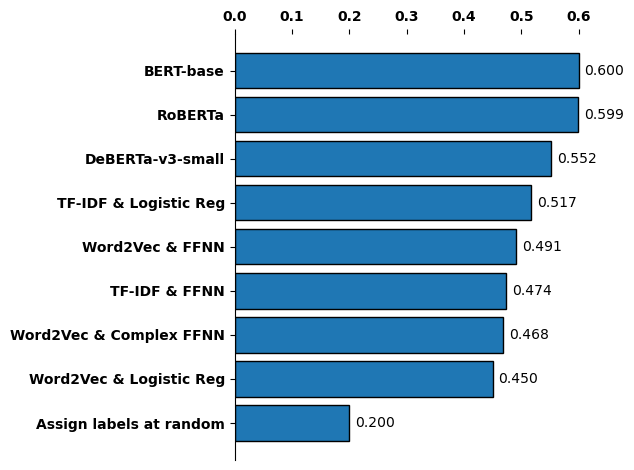

In [14]:
# specifying values
values = [0.600, 0.599, 0.552, 0.517, 0.491, 0.474, 0.468, 0.450, 0.2]
labels = [ 'BERT-base', 'RoBERTa', 'DeBERTa-v3-small', 'TF-IDF & Logistic Reg', 'Word2Vec & FFNN',
           'TF-IDF & FFNN','Word2Vec & Complex FFNN', 'Word2Vec & Logistic Reg', 'Assign labels at random']

# plot the figure
plt.figure()
bars = plt.barh(labels,values,edgecolor='black')

# add corresponding values to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width+0.01, bar.get_y()+bar.get_height()/2,f'{width:.3f}',va='center')
    
plt.gca().invert_yaxis()
for spine in ['top','right','bottom']:plt.gca().spines[spine].set_visible(False)
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')

plt.xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()